<a href="https://colab.research.google.com/github/Phong03102003/DATN/blob/main/2121050606_NguyenHoangTungPhong_DLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Giới thiệu về dữ liệu

# 2. Khám phá dữ liệu

In [ ]:
# Kết nối drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cài đặt thư viện
!pip install ultralytics opencv-python-headless matplotlib -q

!pip install opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.6 MB/s eta 0:00:00


In [ ]:
# Khai báo thư viện
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
import xml.etree.ElementTree as ET
import pandas as pd
import seaborn as sns

In [ ]:
# Đường dẫn đến file dữ liệu, video

video_path = '/content/drive/MyDrive/2121050606_Phong/Data/DJI_0012.MOV'
xml_path = '/content/drive/MyDrive/2121050606_Phong/Data/DJI_0012_data.xml'

## 2.1 Kiểm tra thông số video

In [ ]:
cap = cv2.VideoCapture(video_path)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Thông số video:")
print(f"Độ phân giải: {w}x{h}")
print(f"FPS: {fps}")
print(f"Tổng số frames: {total_frames}")
print(f"Thời lượng: {total_frames/fps:.2f} giây")
cap.release()

Thông số video:
Độ phân giải: 3840x2160
FPS: 25.0
Tổng số frames: 11309
Thời lượng: 452.36 giây


Kích thước frame: (2160, 3840, 3)


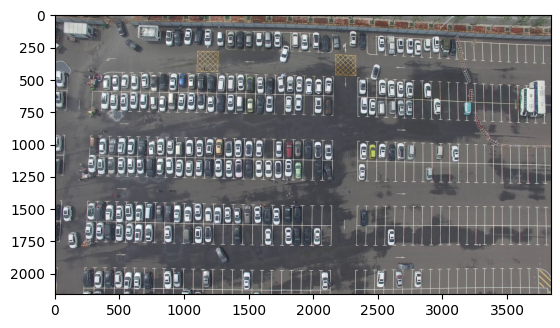

In [ ]:
# Cắt 1 frame từ video
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)
ret, frame = cap.read()
cap.release()
if ret:
    # hiển thị hình ảnh
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.show
    print(f"Kích thước frame: {frame.shape}")
    # lưu hình ảnh vào drive
    cv2.imwrite('./2121050606_Phong/Data/frame_100.jpg', frame)
else:
    print("Không thể đọc frame")

## 2.2 Kiểm tra cấu trúc XML

In [ ]:
tree = ET.parse(xml_path)
root = tree.getroot()

# Đếm tổng số xe trong XML (theo ID trajectory)
vehicles = set()
for frame in root.findall('frame'):
    for traj in frame.findall('trajectory'):
        if traj.get('type') in ['Car', 'Bus', 'Medium Vehicle']:
            vehicles.add(traj.get('id'))

print(f"Tổng số phương tiện (unique ID) được gán nhãn: {len(vehicles)}")

Tổng số phương tiện (unique ID) được gán nhãn: 231


# 3. Tiền xử lý dữ liệu

In [ ]:
# Đường dẫn lưu dữ liệu sau xử lý
base_dir = '/content/drive/MyDrive/2121050606_Phong/Data/data_oke'
train_img_dir = os.path.join(base_dir, 'images/train')
train_lbl_dir = os.path.join(base_dir, 'labels/train')
val_img_dir = os.path.join(base_dir, 'images/val')
val_lbl_dir = os.path.join(base_dir, 'labels/val')

# Thông số kỹ thuật
target_size = (1920, 1080)   # Resize về Full HD cho nhẹ
orig_w = w # Chiều rộng gốc của video 4K (dùng để chia tỷ lệ)
orig_h = h # Chiều cao gốc của video 4K

sample_rate = 25             # Cứ 25 khung hình thì lấy 1 ảnh (1 giây/ảnh)
val_ratio = 0.2              # 20% dữ liệu dùng để kiểm thử (Validation)

# Các loại xe cần bắt (Lọc bỏ người đi bộ, xe máy,...)
target_classes = ["Car", "Bus", "Medium Vehicle"]

In [ ]:
# Chuẩn bị thư mục lưu dữ liệu
# Hàm tạo lại thư mục
def recreate_dir(dir_path):
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)  # Xóa thư mục cũ
    os.makedirs(dir_path, exist_ok=True) # Tạo thư mục mới

# Tạo cấu trúc thư mục chuẩn YOLO
recreate_dir(train_img_dir)
recreate_dir(train_lbl_dir)
recreate_dir(val_img_dir)
recreate_dir(val_lbl_dir)

print(f"Đã tạo thư mục: {base_dir}")

Đã tạo thư mục: /content/drive/MyDrive/2121050606_Phong/Data/data_oke


In [ ]:
# Hàm tính toán tọa độ YOLO
# Input: Tọa độ 4 góc của xe trong XML.
# Output: Chuỗi text chuẩn YOLO (class_id x_center y_center w h).
def convert_to_yolo_format(traj_item, img_w, img_h):
    """
    Hàm này lấy thông tin từ thẻ XML <trajectory> và trả về dòng text chuẩn YOLO.
    """
    try:
        # 1. Lấy tọa độ 4 góc của xe (front_left, front_right, rear_left, rear_right)
        x_coords = [
            float(traj_item.get('front_left_x')), float(traj_item.get('front_right_x')),
            float(traj_item.get('rear_left_x')), float(traj_item.get('rear_right_x'))
        ]
        y_coords = [
            float(traj_item.get('front_left_y')), float(traj_item.get('front_right_y')),
            float(traj_item.get('rear_left_y')), float(traj_item.get('rear_right_y'))
        ]

        # 2. Tìm hình chữ nhật bao quanh (Bounding Box)
        x_min = min(x_coords)
        x_max = max(x_coords)
        y_min = min(y_coords)
        y_max = max(y_coords)

        # 3. Chuẩn hóa về khoảng [0, 1] theo kích thước ảnh gốc
        x_center = ((x_min + x_max) / 2) / img_w
        y_center = ((y_min + y_max) / 2) / img_h
        width = (x_max - x_min) / img_w
        height = (y_max - y_min) / img_h

        # 4. Giới hạn giá trị không vượt quá 1 hoặc nhỏ hơn 0 (phòng lỗi)
        x_center = max(0, min(1, x_center))
        y_center = max(0, min(1, y_center))
        width = max(0, min(1, width))
        height = max(0, min(1, height))

        # Trả về chuỗi: "0 x y w h" (0 là class_id cho xe cộ)
        return f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"

    except Exception as e:
        return None

In [ ]:
# Đọc video -> Cắt ảnh -> Ghép nhãn -> Lưu file.
import time

# 1. Tạo mục lục cho xml để giảm tải cpu
print("Đang tạo mục lục cho XML")
tree = ET.parse(xml_path)
root = tree.getroot()

# Tạo từ điển: { frame_id: [danh_sách_xe] }
# Tra cứu từ điển nhanh gấp nghìn lần so với root.find()
xml_index = {}

# Duyệt qua XML một lần duy nhất để gom nhóm xe theo frame
for frame in root.findall('frame'):
    f_id = int(frame.get('id'))

    # Chỉ lưu những frame nằm trong nhịp lấy mẫu (đỡ tốn RAM)
    if f_id % sample_rate == 0:
        vehicles = []
        for traj in frame.findall('trajectory'):
            if traj.get('type') in target_classes:
                vehicles.append(traj)

        if vehicles: # Chỉ lưu nếu frame đó có xe cần bắt
            xml_index[f_id] = vehicles

print(f"Đã đánh chỉ mục xong {len(xml_index)} khung hình có chứa xe.")


# 2. Xử lý video
cap = cv2.VideoCapture(video_path)
total_frames_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_idx = 0
saved_count = 0
start_time = time.time()

print(f"Bắt đầu xử lý toàn bộ video({total_frames_video} frames):")

while True:

    # Trường hợp 1: Frame không cần lấy mẫu (Bỏ qua để tiết kiệm CPU)
    if frame_idx % sample_rate != 0:
        ret = cap.grab()  # Chỉ tua qua, không giải mã hình ảnh
        if not ret:
            break # Hết video
        frame_idx += 1
        continue

    # Trường hợp 2: Frame CẦN lấy mẫu (Frame 0, 25, 50...)
    else:
        ret, frame = cap.read() # Đọc đầy đủ hình ảnh
        if not ret:
            break # Hết video

        # Chỉ xử lý nếu frame này có trong XML (có xe)
        if frame_idx in xml_index:
            vehicles_in_frame = xml_index[frame_idx]

            # 2.1. Resize ảnh
            resized_frame = cv2.resize(frame, target_size)

            # 2.2. Quyết định Train/Val
            is_validation = np.random.rand() < val_ratio
            save_img_path = val_img_dir if is_validation else train_img_dir
            save_lbl_path = val_lbl_dir if is_validation else train_lbl_dir

            filename = f"frame_{frame_idx:06d}"

            # 2.3. Tạo list nhãn YOLO
            yolo_labels = []
            for vehicle in vehicles_in_frame:
                yolo_line = convert_to_yolo_format(vehicle, orig_w, orig_h)
                if yolo_line:
                    yolo_labels.append(yolo_line)

            # 4. Lưu file nếu có nhãn
            if len(yolo_labels) > 0:
                cv2.imwrite(f"{save_img_path}/{filename}.jpg", resized_frame)
                with open(f"{save_lbl_path}/{filename}.txt", "w") as f:
                    f.write("\n".join(yolo_labels))

                saved_count += 1

                if saved_count % 50 == 0:
                    elapsed = time.time() - start_time
                    print(f"--> Đã lưu {saved_count} ảnh... (Frame: {frame_idx} - {elapsed:.1f}s)")

        frame_idx += 1

cap.release()
total_time = (time.time() - start_time) / 60
print(f"Hoàn thành!")
print(f"Tổng thời gian: {total_time:.2f} phút")
print(f"Tổng số ảnh đã tạo: {saved_count}")
print(f"Kiểm tra thư mục dataset tại: {base_dir}")

Đang tạo mục lục cho XML
Đã đánh chỉ mục xong 453 khung hình có chứa xe.
Bắt đầu xử lý toàn bộ video(11309 frames):
--> Đã lưu 50 ảnh... (Frame: 1225 - 87.2s)
--> Đã lưu 100 ảnh... (Frame: 2475 - 174.4s)
--> Đã lưu 150 ảnh... (Frame: 3725 - 262.1s)
--> Đã lưu 200 ảnh... (Frame: 4975 - 348.2s)
--> Đã lưu 250 ảnh... (Frame: 6225 - 440.5s)
--> Đã lưu 300 ảnh... (Frame: 7475 - 528.0s)
--> Đã lưu 350 ảnh... (Frame: 8725 - 613.1s)
--> Đã lưu 400 ảnh... (Frame: 9975 - 701.6s)
--> Đã lưu 450 ảnh... (Frame: 11225 - 785.8s)
Hoàn thành!
Tổng thời gian: 13.21 phút
Tổng số ảnh đã tạo: 453
Kiểm tra thư mục dataset tại: /content/drive/MyDrive/2121050606_Phong/Data/data_oke


Mặc dù con số 453 ảnh có vẻ khiêm tốn so với các bộ dữ liệu phổ quát (như COCO hay ImageNet), nhưng đây là kích thước tối ưu và chất lượng cao cho bài toán cụ thể này vì các lý do sau:

Mật độ đối tượng cao (High Instance Density): Đặc thù của bãi đỗ xe là mật độ xe rất dày. Trung bình mỗi bức ảnh chứa từ 50 đến hơn 100 phương tiện. Do đó, tổng số lượng nhãn (bounding boxes) thực tế mà mô hình được học lên tới hơn 20,000 mẫu xe. Đây là con số rất lớn, đảm bảo mô hình học được đa dạng các biến thể của đối tượng.

Giảm thiểu tính dư thừa (Redundancy Reduction): Dữ liệu được thu thập từ camera cố định (Fixed Camera). Sự thay đổi giữa các khung hình liên tiếp là rất ít (xe đỗ tĩnh). Việc lấy mẫu quá dày (ví dụ: lấy 2000 ảnh) sẽ chỉ tạo ra hàng nghìn bức ảnh trùng lặp thông tin, dễ dẫn đến hiện tượng học vẹt (Overfitting) và lãng phí tài nguyên tính toán mà không cải thiện độ chính xác.

Hiệu quả huấn luyện: Với 453 ảnh chất lượng cao (đã lọc nhiễu, gán nhãn chuẩn từ XML), thời gian huấn luyện mô hình YOLOv8 được rút ngắn đáng kể (ước tính 15-30 phút trên GPU T4), tạo điều kiện thuận lợi cho việc tinh chỉnh tham số (Hyperparameter Tuning) và thử nghiệm nhiều lần trong khuôn khổ đồ án.

Khả năng Augmentation của YOLO: Trong quá trình huấn luyện, YOLOv8 sử dụng kỹ thuật Mosaic Augmentation (ghép 4 ảnh thành 1, xoay, lật, chỉnh sáng...). Do đó, từ 453 ảnh gốc, mô hình thực tế sẽ được học trên hàng nghìn biến thể hình ảnh khác nhau, đảm bảo độ bền vững (Robustness) khi triển khai thực tế.

Kết luận: Bộ dữ liệu sau tiền xử lý đảm bảo tính Cân bằng - Chất lượng - Hiệu quả, hoàn toàn đáp ứng tốt yêu cầu huấn luyện mô hình phát hiện xe cho đồ án tốt nghiệp.

In [ ]:
# Tạo file data.yaml
# Đường dẫn gốc tới thư mục dữ liệu của bạn
dataset_location = '/content/drive/MyDrive/2121050606_Phong/Data/data_oke'

# Nội dung file yaml
yaml_content = f"""
# Đường dẫn gốc (Absolute path)
path: {dataset_location}

# Đường dẫn tương đối đến thư mục ảnh (Relative paths)
train: images/train
val: images/val

# Số lượng lớp (classes)
nc: 1

# Tên các lớp
names: ['Vehicle']
"""

# Tạo file data.yaml nằm ngay trong thư mục dataset
yaml_path = os.path.join(dataset_location, 'data.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"Đã tạo: {yaml_path}")
print("Nội dung file:")
print(yaml_content)

Đã tạo: /content/drive/MyDrive/2121050606_Phong/Data/data_oke/data.yaml
Nội dung file:

# Đường dẫn gốc (Absolute path)
path: /content/drive/MyDrive/2121050606_Phong/Data/data_oke

# Đường dẫn tương đối đến thư mục ảnh (Relative paths)
train: images/train
val: images/val

# Số lượng lớp (classes)
nc: 1

# Tên các lớp
names: ['Vehicle']



Đang kiểm tra dữ liệu từ: /content/drive/MyDrive/2121050606_Phong/Data/data_oke/images/train


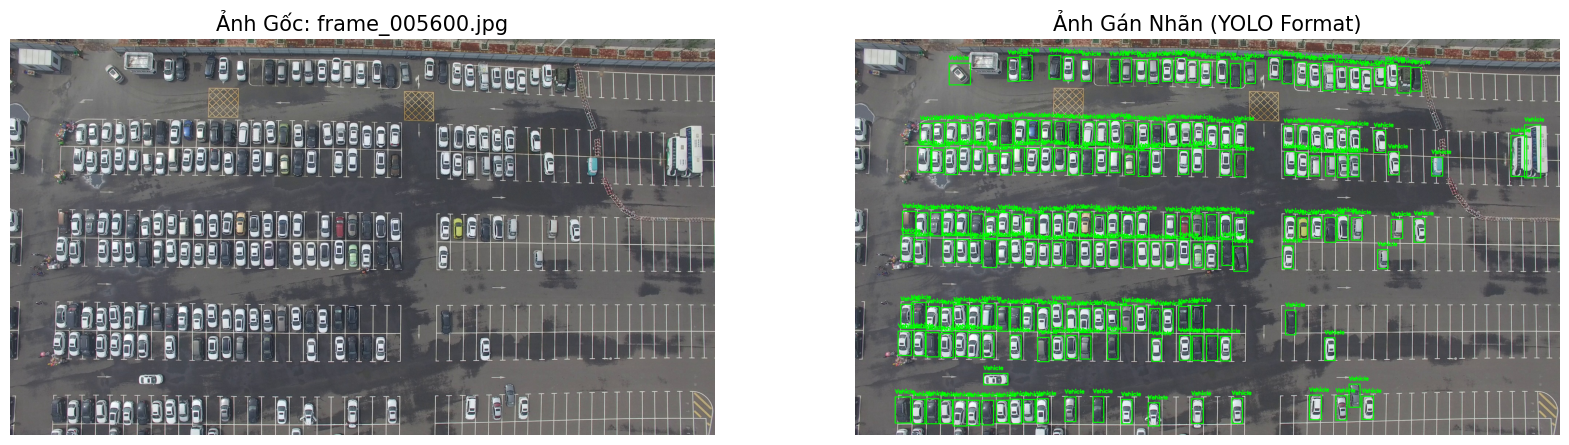

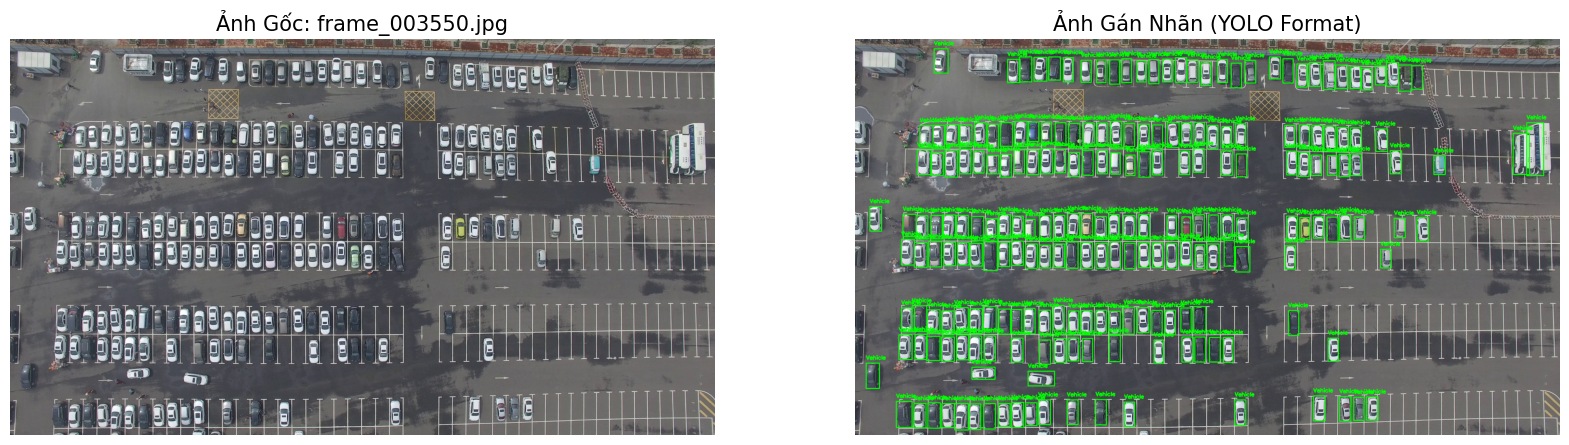

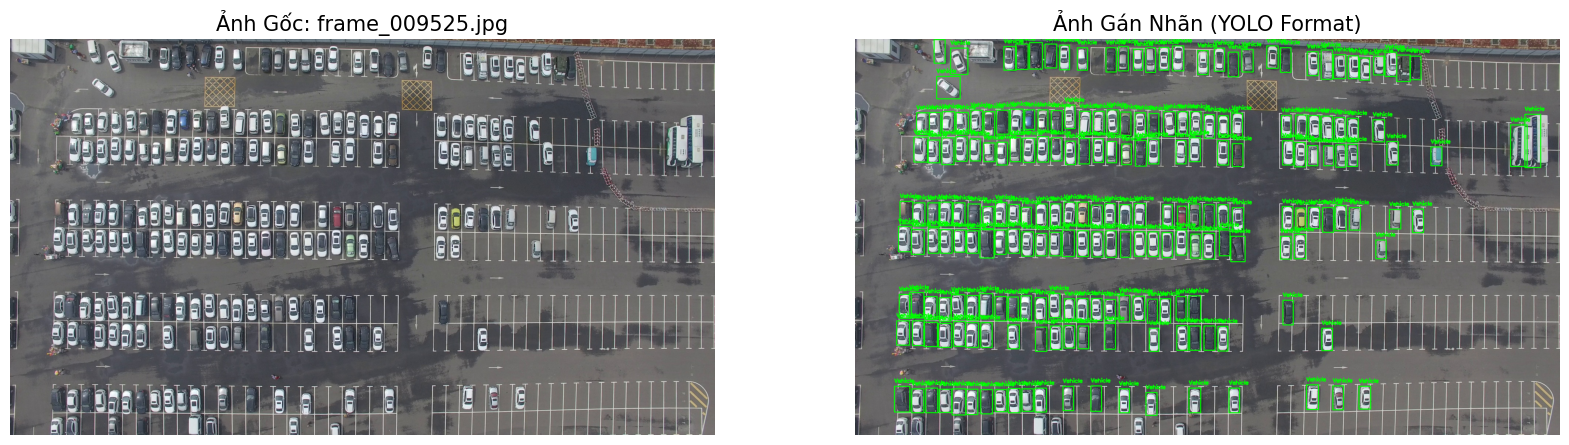

In [ ]:
import random
import glob

train_img_dir = os.path.join(dataset_location, 'images/train')
train_lbl_dir = os.path.join(dataset_location, 'labels/train')

def visualize_sample(num_samples=3):
    # Lấy danh sách tất cả file ảnh jpg
    image_files = glob.glob(os.path.join(train_img_dir, '*.jpg'))

    if not image_files:
        print("Không tìm thấy ảnh nào trong thư mục train!")
        return

    # Chọn ngẫu nhiên num_samples ảnh
    samples = random.sample(image_files, min(len(image_files), num_samples))

    for img_path in samples:
        # 1. Đọc ảnh gốc
        img = cv2.imread(img_path)
        if img is None: continue

        # Chuyển BGR (OpenCV) sang RGB (Matplotlib) để hiển thị đúng màu
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h_img, w_img, _ = img.shape

        # Tạo một bản sao để vẽ nhãn lên (Ảnh sau khi gán nhãn)
        img_labeled = img_rgb.copy()

        # 2. Tìm file nhãn tương ứng
        # Quy tắc: .../images/train/abc.jpg -> .../labels/train/abc.txt
        lbl_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')

        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    # Đọc tọa độ YOLO: class x_center y_center w h
                    parts = list(map(float, line.strip().split()))
                    cls_id = int(parts[0])
                    x_c, y_c, w, h = parts[1:]

                    # 3. Chuyển đổi từ YOLO (0-1) sang Pixel (0-1920)
                    x1 = int((x_c - w / 2) * w_img)
                    y1 = int((y_c - h / 2) * h_img)
                    x2 = int((x_c + w / 2) * w_img)
                    y2 = int((y_c + h / 2) * h_img)

                    # Vẽ hình chữ nhật (Màu xanh lá cây, độ dày 3)
                    cv2.rectangle(img_labeled, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    # Viết tên lớp (Vehicle)
                    cv2.putText(img_labeled, "Vehicle", (x1, y1 - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        # 4. Hiển thị 2 ảnh cạnh nhau: Gốc vs Có nhãn
        fig, axes = plt.subplots(1, 2, figsize=(20, 10))

        # Ảnh gốc
        axes[0].imshow(img_rgb)
        axes[0].set_title(f"Ảnh Gốc: {os.path.basename(img_path)}", fontsize=15)
        axes[0].axis('off')

        # Ảnh có nhãn
        axes[1].imshow(img_labeled)
        axes[1].set_title(f"Ảnh Gán Nhãn (YOLO Format)", fontsize=15)
        axes[1].axis('off')

        plt.show()

# Chạy hàm hiển thị
print(f"Đang kiểm tra dữ liệu từ: {train_img_dir}")
visualize_sample(3) # Hiển thị 3 cặp ảnh